In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/annotations/scratches_246.xml
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/annotations/patches_258.xml
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/annotations/crazing_241.xml
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/annotations/patches_267.xml
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/annotations/crazing_270.xml
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/annotations/pitted_surface_256.xml
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/annotations/pitted_surface_265.xml
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/annotations/pitted_surface_287.xml
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-databas

In [3]:
# ── CELL 1 ── Install & Imports ──────────────────────────────
import subprocess
subprocess.run(["pip", "install", "reportlab", "-q"], check=True)
 
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from collections import Counter
 
warnings.filterwarnings("ignore")
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
 
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device  :", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.2 MB/s eta 0:00:00
PyTorch : 2.10.0+cu128
CUDA    : True
Device  : cuda


In [4]:
 
# ── CELL 2 ── Config & Paths ─────────────────────────────────
TRAIN_DIR = "/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/train/images"
VAL_DIR   = "/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/images"
 
CLASSES = [
    'crazing', 'inclusion', 'patches',
    'pitted_surface', 'rolled-in_scale', 'scratches'
]
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for i, c in enumerate(CLASSES)}
 
IMG_SIZE   = 224          # safe for T4 with B3
BATCH_SIZE = 16
EPOCHS     = 25
LR         = 1e-4
SEED       = 42
 
torch.manual_seed(SEED)
np.random.seed(SEED)
print("Classes:", CLASSES)

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


                 Train  Validation
crazing            240          60
inclusion          240          60
patches            240          60
pitted_surface     240          60
rolled-in_scale    240          60
scratches          240          60

Total → Train: 1440 | Val: 360


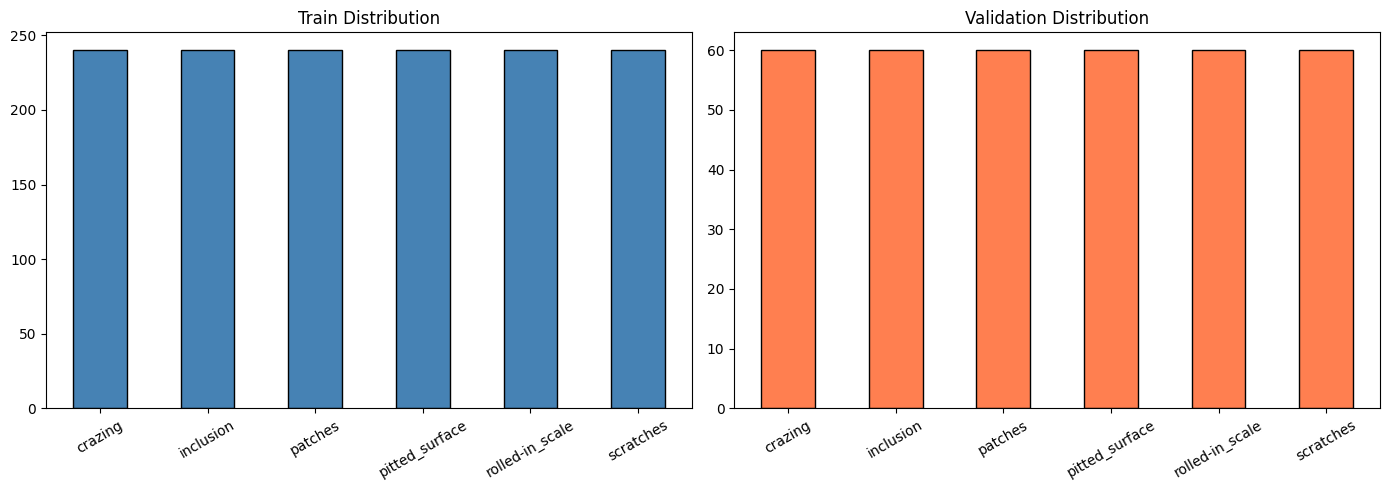

In [5]:
 
# ── CELL 3 ── Explore Dataset ────────────────────────────────
def count_images(root):
    return {
        cls: len([
            f for f in os.listdir(os.path.join(root, cls))
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
        ]) if os.path.exists(os.path.join(root, cls)) else 0
        for cls in CLASSES
    }
 
train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
df_counts    = pd.DataFrame({'Train': train_counts, 'Validation': val_counts})
print(df_counts)
print(f"\nTotal → Train: {sum(train_counts.values())} | Val: {sum(val_counts.values())}")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_counts['Train'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Train Distribution'); axes[0].tick_params(axis='x', rotation=30)
df_counts['Validation'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Validation Distribution'); axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution.png', dpi=150)
plt.show()

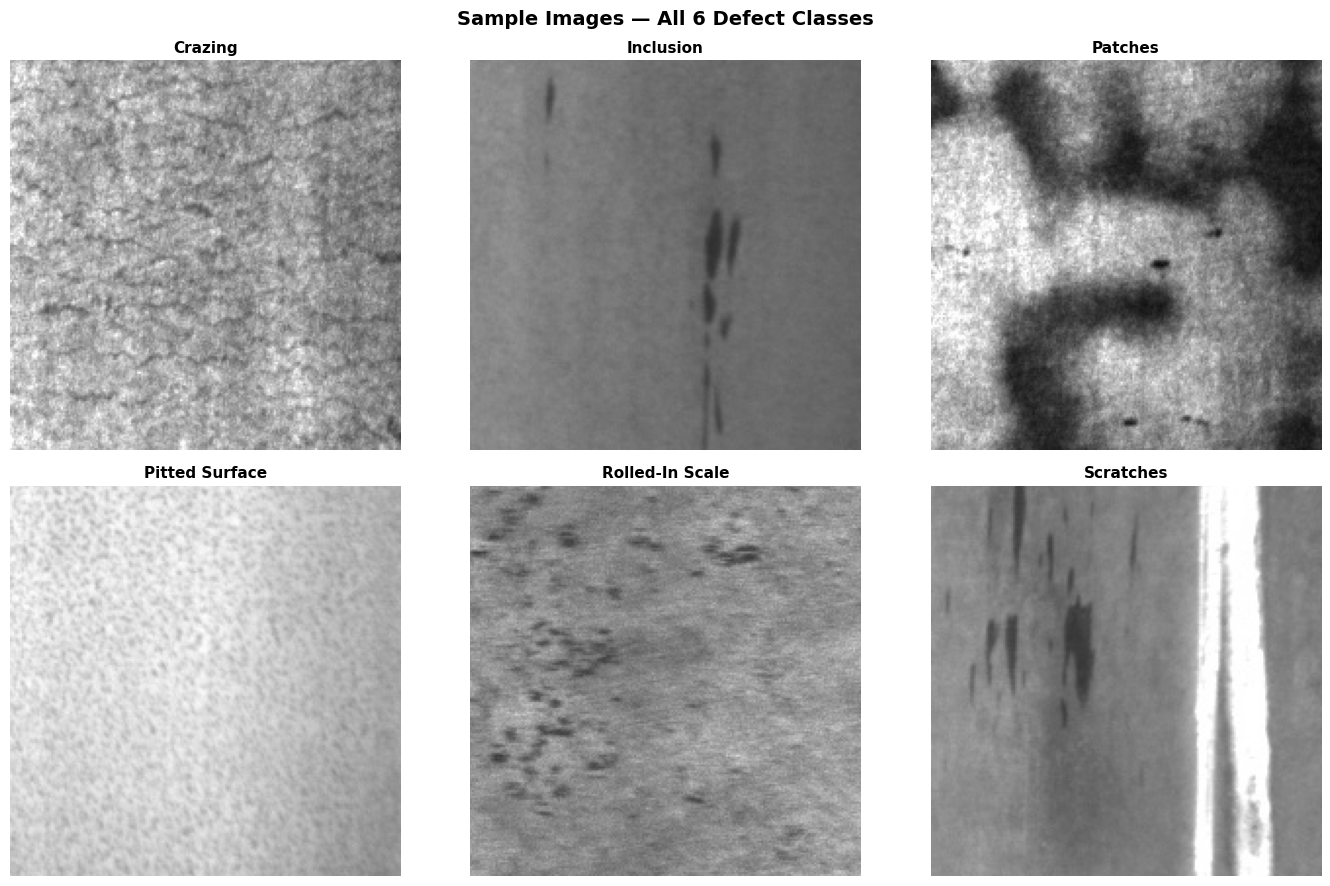

In [6]:
# ── CELL 4 ── Sample Images ──────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for i, cls in enumerate(CLASSES):
    p = os.path.join(TRAIN_DIR, cls)
    img = Image.open(os.path.join(p, os.listdir(p)[0])).convert('RGB')
    axes[i//3][i%3].imshow(img, cmap='gray')
    axes[i//3][i%3].set_title(cls.replace('_',' ').title(), fontsize=11, fontweight='bold')
    axes[i//3][i%3].axis('off')
plt.suptitle('Sample Images — All 6 Defect Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:

# ── CELL 5 ── Dataset & DataLoaders ─────────────────────────
class SteelDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples  = []
        self.transform = transform
        for cls in CLASSES:
            p = os.path.join(root_dir, cls)
            if not os.path.exists(p):
                continue
            for f in os.listdir(p):
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    self.samples.append((os.path.join(p, f), CLASS_TO_IDX[cls]))
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label
 
 
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
 
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
 
train_dataset = SteelDataset(TRAIN_DIR, train_transform)
val_dataset   = SteelDataset(VAL_DIR,   val_transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
 
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
 


Train: 1440 | Val: 360


In [8]:

# ── CELL 6 ── Model (EfficientNet-B3) ───────────────────────
model = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
for p in model.parameters():
    p.requires_grad = False
for p in model.features[6:].parameters():
    p.requires_grad = True
 
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES)
)
model = model.to(device)
 
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total:,} | Trainable: {trainable:,}")
 

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 172MB/s]


Total params: 11,486,254 | Trainable: 9,296,100


In [9]:
# ── CELL 7 ── Loss, Optimizer, Scheduler ────────────────────
y_train = [s[1] for s in train_dataset.samples]
cls_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train
)
cls_weights = torch.tensor(cls_weights, dtype=torch.float32).to(device)
print("Class weights:", cls_weights.cpu().numpy())
 
criterion = nn.CrossEntropyLoss(weight=cls_weights, label_smoothing=0.1)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

Class weights: [1. 1. 1. 1. 1. 1.]


In [10]:
# ── CELL 8 ── Early Stopping ─────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=6):
        self.patience = patience
        self.best     = 0.0
        self.counter  = 0
 
    def step(self, score):
        if score > self.best:
            self.best    = score
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience
 
 
# ── CELL 9 ── Train & Evaluate Functions ────────────────────
def train_epoch():
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct    += out.argmax(1).eq(y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / total
 
 
def evaluate():
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out  = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(val_dataset), acc, f1, all_preds, all_labels
 

In [11]:
# ── CELL 10 ── Training Loop ─────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
early   = EarlyStopping(patience=6)
best_acc = 0.0
 
print(f"\n{'Ep':>3} | {'TLoss':>7} | {'TAcc':>6} | {'VLoss':>7} | {'VAcc':>6} | {'F1':>6} | {'LR':>8}")
print("─" * 60)
 
for epoch in range(1, EPOCHS + 1):
    tl, ta           = train_epoch()
    vl, va, vf, vp, vl_labels = evaluate()
    scheduler.step()
 
    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['train_acc'].append(ta)
    history['val_acc'].append(va)
    history['val_f1'].append(vf)
 
    lr_now = scheduler.get_last_lr()[0]
    print(f"{epoch:>3} | {tl:>7.4f} | {ta:>5.2%} | {vl:>7.4f} | {va:>5.2%} | {vf:>5.3f} | {lr_now:.2e}")
 
    if va > best_acc:
        best_acc = va
        torch.save(model.state_dict(), '/kaggle/working/best_model.pth')
        print(f"      ✓ Saved best model (val_acc={va:.2%})")
 
    if early.step(va):
        print(f"\n⚠ Early stopping at epoch {epoch}")
        break
 
print(f"\nBest Val Accuracy: {best_acc:.2%}")
 
# Keep last epoch's preds/labels for report
final_preds, final_labels = vp, vl_labels


 Ep |   TLoss |   TAcc |   VLoss |   VAcc |     F1 |       LR
────────────────────────────────────────────────────────────
  1 |  1.2018 | 79.65% |  0.6239 | 96.11% | 0.961 | 9.96e-05
      ✓ Saved best model (val_acc=96.11%)
  2 |  0.5394 | 96.88% |  0.5004 | 98.33% | 0.983 | 9.84e-05
      ✓ Saved best model (val_acc=98.33%)
  3 |  0.4949 | 98.40% |  0.4665 | 98.89% | 0.989 | 9.65e-05
      ✓ Saved best model (val_acc=98.89%)
  4 |  0.4824 | 98.54% |  0.4504 | 99.72% | 0.997 | 9.39e-05
      ✓ Saved best model (val_acc=99.72%)
  5 |  0.4852 | 98.61% |  0.4522 | 100.00% | 1.000 | 9.05e-05
      ✓ Saved best model (val_acc=100.00%)
  6 |  0.4789 | 98.47% |  0.4477 | 99.72% | 0.997 | 8.66e-05
  7 |  0.4735 | 98.89% |  0.4382 | 100.00% | 1.000 | 8.21e-05
  8 |  0.4642 | 99.24% |  0.4452 | 99.72% | 0.997 | 7.70e-05
  9 |  0.4612 | 99.44% |  0.4394 | 99.72% | 0.997 | 7.16e-05
 10 |  0.4587 | 99.24% |  0.4351 | 99.72% | 0.997 | 6.58e-05
 11 |  0.4530 | 99.65% |  0.4371 | 100.00% | 1.000 | 

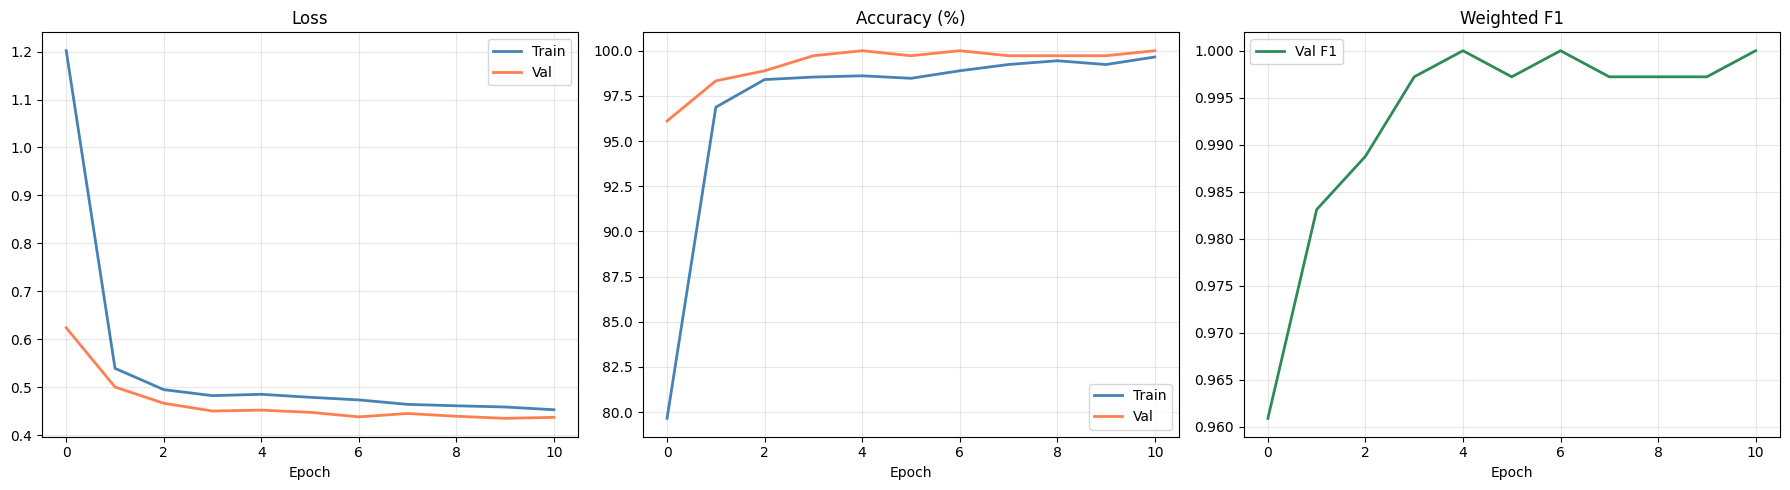

In [12]:
 
# ── CELL 11 ── Training Curves ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
axes[0].plot(history['train_loss'], label='Train', color='steelblue', lw=2)
axes[0].plot(history['val_loss'],   label='Val',   color='coral',     lw=2)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
 
axes[1].plot([a*100 for a in history['train_acc']], label='Train', color='steelblue', lw=2)
axes[1].plot([a*100 for a in history['val_acc']],   label='Val',   color='coral',     lw=2)
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
 
axes[2].plot(history['val_f1'], label='Val F1', color='seagreen', lw=2)
axes[2].set_title('Weighted F1'); axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()
 

Best Model → Val Acc: 100.00% | Weighted F1: 1.0000

                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        60
      inclusion       1.00      1.00      1.00        60
        patches       1.00      1.00      1.00        60
 pitted_surface       1.00      1.00      1.00        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       1.00      1.00      1.00        60

       accuracy                           1.00       360
      macro avg       1.00      1.00      1.00       360
   weighted avg       1.00      1.00      1.00       360



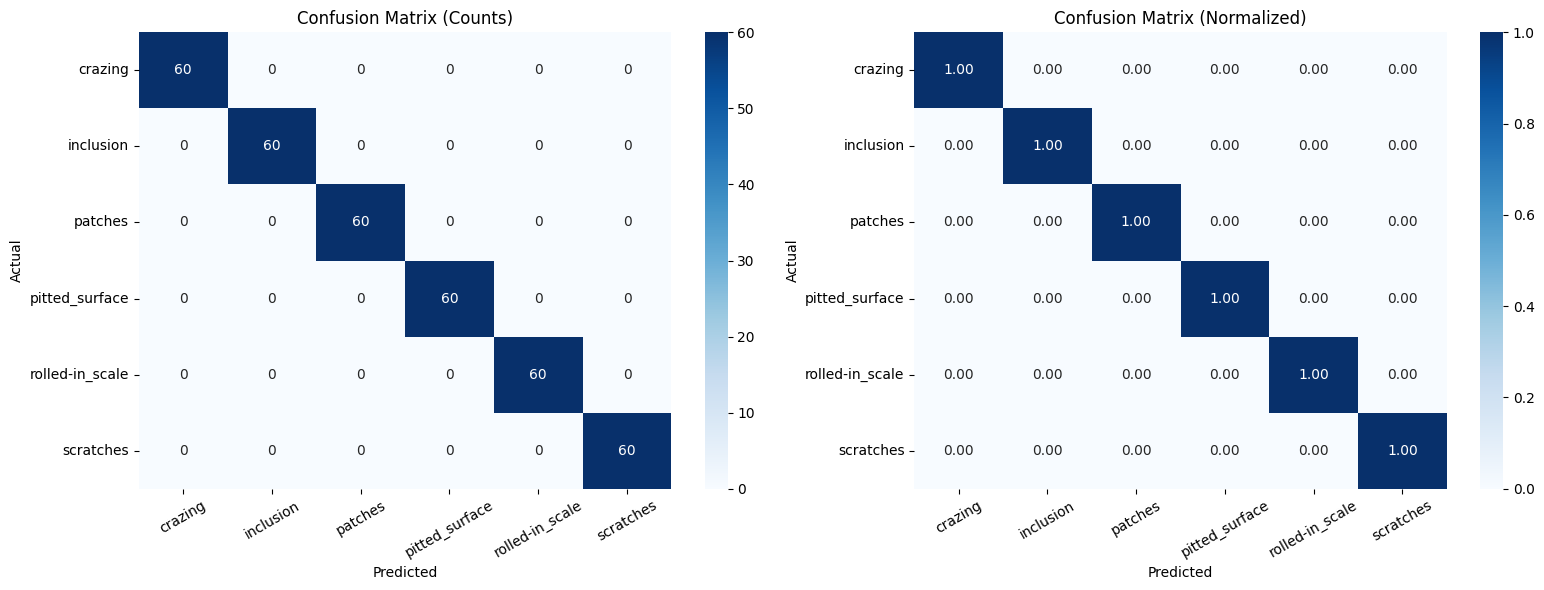

In [13]:
 
# ── CELL 12 ── Load Best & Classification Report ─────────────
model.load_state_dict(torch.load('/kaggle/working/best_model.pth', map_location=device))
_, best_val_acc, best_f1, final_preds, final_labels = evaluate()
 
print(f"Best Model → Val Acc: {best_val_acc:.2%} | Weighted F1: {best_f1:.4f}\n")
print(classification_report(final_labels, final_preds, target_names=CLASSES))
 
 
# ── CELL 13 ── Confusion Matrix ──────────────────────────────
cm      = confusion_matrix(final_labels, final_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm,      annot=True, fmt='d',    cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
sns.heatmap(cm_norm, annot=True, fmt='.2f',  cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
for ax, title in zip(axes, ['Confusion Matrix (Counts)', 'Confusion Matrix (Normalized)']):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
 

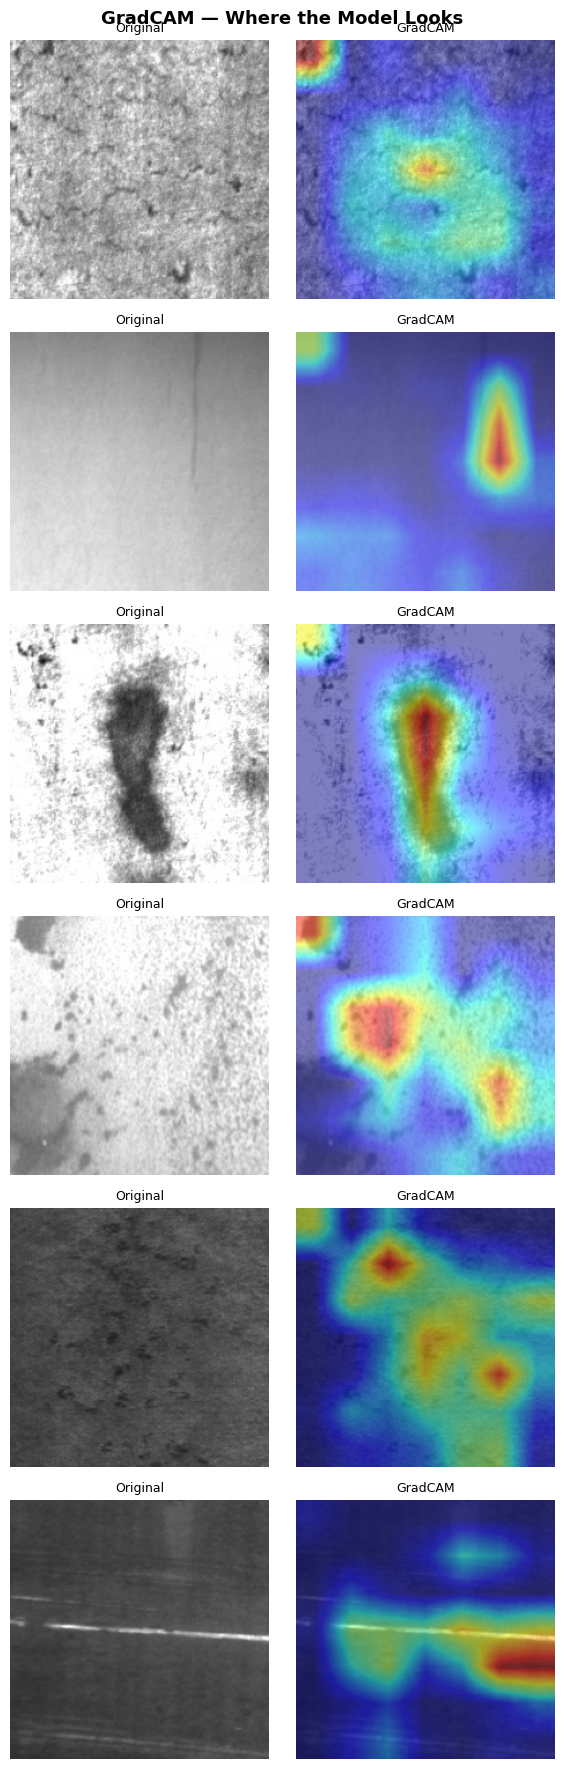

In [14]:

# ── CELL 14 ── GradCAM ───────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)
 
    def _save_activation(self, module, input, output):
        self.activations = output.detach()
 
    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
 
    def generate(self, x, class_idx=None):
        self.model.eval()
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(1).item()
        self.model.zero_grad()
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = torch.relu(cam)
        cam     = cam - cam.min()
        cam     = cam / (cam.max() + 1e-8)
        return cam.squeeze().cpu().numpy()
 
 
# Attach GradCAM to last conv block
gradcam = GradCAM(model, model.features[-1])
 
def show_gradcam(image_path, ax_orig, ax_cam):
    img_pil = Image.open(image_path).convert('RGB')
    x       = val_transform(img_pil).unsqueeze(0).to(device)
    cam     = gradcam.generate(x)
    cam_resized = np.array(
        Image.fromarray((cam * 255).astype(np.uint8)).resize(
            (IMG_SIZE, IMG_SIZE), Image.BILINEAR
        )
    ) / 255.0
    img_np = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE))) / 255.0
    heatmap = plt.cm.jet(cam_resized)[:, :, :3]
    overlay = 0.5 * img_np + 0.5 * heatmap
    ax_orig.imshow(img_np); ax_orig.axis('off'); ax_orig.set_title('Original', fontsize=9)
    ax_cam.imshow(overlay);  ax_cam.axis('off');  ax_cam.set_title('GradCAM',  fontsize=9)
 
fig, axes = plt.subplots(NUM_CLASSES, 2, figsize=(6, 3 * NUM_CLASSES))
for i, cls in enumerate(CLASSES):
    p   = os.path.join(VAL_DIR, cls)
    img = os.path.join(p, os.listdir(p)[0])
    show_gradcam(img, axes[i][0], axes[i][1])
    axes[i][0].set_ylabel(cls.replace('_',' '), fontsize=9, rotation=90, labelpad=40)
 
plt.suptitle('GradCAM — Where the Model Looks', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
 

In [15]:
 
# ── CELL 15 ── Root Cause Knowledge Base ─────────────────────
ROOT_CAUSE_KB = {
    'crazing': {
        'description': 'Network of fine cracks on steel surface resembling a spider web.',
        'causes': [
            'Rapid and uneven cooling after rolling or heat treatment',
            'High residual thermal stress during quenching',
            'Improper cooling rate in the cooling bed',
        ],
        'process_checks': [
            'Inspect cooling bed temperature uniformity',
            'Review quenching water temperature and flow rate',
            'Check thermal gradient across the slab cross-section',
        ],
        'corrective_actions': [
            'Reduce quenching rate gradually',
            'Ensure uniform water spray distribution',
            'Preheat steel to reduce thermal shock',
        ]
    },
    'inclusion': {
        'description': 'Non-metallic particles (oxides, sulfides, silicates) embedded in steel matrix.',
        'causes': [
            'Insufficient ladle refining and deslagging',
            'Reoxidation during teeming or casting',
            'Slag entrapment from ladle or tundish',
        ],
        'process_checks': [
            'Review ladle refining time and slag composition',
            'Inspect tundish lining for erosion',
            'Check argon stirring intensity and duration',
        ],
        'corrective_actions': [
            'Improve ladle deslagging practice',
            'Optimize argon purging to prevent reoxidation',
            'Use calcium treatment to globularize inclusions',
        ]
    },
    'patches': {
        'description': 'Irregular surface discoloration or scale patches on steel surface.',
        'causes': [
            'Uneven scale formation during reheating',
            'Inconsistent furnace atmosphere (oxidizing zones)',
            'Improper descaling leaving residual scale',
        ],
        'process_checks': [
            'Monitor furnace temperature profile across length',
            'Inspect descaler nozzle pressure and coverage',
            'Check furnace atmosphere oxygen levels',
        ],
        'corrective_actions': [
            'Optimize furnace heating schedule',
            'Increase descaling water pressure',
            'Ensure uniform slab heating before rolling',
        ]
    },
    'pitted_surface': {
        'description': 'Small craters or pits distributed across the steel surface.',
        'causes': [
            'Scale pressed into the surface during rolling',
            'Corrosion pits from improper storage or handling',
            'Gas porosity from casting reaching the surface',
        ],
        'process_checks': [
            'Inspect descaling effectiveness before each rolling pass',
            'Review slab storage conditions for moisture exposure',
            'Check mold powder consumption during casting',
        ],
        'corrective_actions': [
            'Improve descaling before finishing rolling pass',
            'Control storage humidity and apply rust inhibitor',
            'Optimize casting speed and mold oscillation',
        ]
    },
    'rolled-in_scale': {
        'description': 'Oxide scale folded into the steel surface during rolling.',
        'causes': [
            'Inadequate descaling before hot rolling passes',
            'Excessive furnace scale formation (high temp / long soak)',
            'Low descaling water pressure or blocked nozzles',
        ],
        'process_checks': [
            'Check descaler nozzle condition and pressure logs',
            'Review reheating furnace temperature and soaking time',
            'Inspect inter-pass descaling between rolling stands',
        ],
        'corrective_actions': [
            'Increase descaling pressure to ≥180 bar',
            'Reduce furnace soaking time at peak temperature',
            'Schedule regular descaler nozzle maintenance',
        ]
    },
    'scratches': {
        'description': 'Linear surface marks caused by mechanical contact or abrasion.',
        'causes': [
            'Damaged or worn roller table guides',
            'Foreign debris on roller surface',
            'Improper handling during transport or coiling',
        ],
        'process_checks': [
            'Inspect all roller surfaces and side guides for wear',
            'Check coiler mandrel and pinch roll condition',
            'Review material handling equipment for sharp edges',
        ],
        'corrective_actions': [
            'Replace or resurface worn roller guides',
            'Clear debris from roller tables before rolling',
            'Improve coiling tension control to avoid slippage',
        ]
    }
}
 

In [17]:
 
# ── CELL 16 ── Severity & RPN Risk ───────────────────────────
def get_severity(conf):
    if conf >= 0.95: return "🔴 Critical"
    if conf >= 0.85: return "🟠 Moderate"
    return "🟢 Minor"
 
RPN = {
    'inclusion':       10,
    'rolled-in_scale':  9,
    'crazing':          8,
    'pitted_surface':   7,
    'patches':          5,
    'scratches':        4,
}
 
 
# ── CELL 17 ── Predict + Root Cause Output ───────────────────
def predict_full(image_path):
    img_pil = Image.open(image_path).convert('RGB')
    x       = val_transform(img_pil).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        out   = model(x)
        probs = torch.softmax(out, dim=1).squeeze().cpu().numpy()
    idx     = np.argmax(probs)
    defect  = IDX_TO_CLASS[idx]
    conf    = probs[idx]
    info    = ROOT_CAUSE_KB[defect]
 
    print("=" * 62)
    print(f"  DEFECT    : {defect.replace('_',' ').upper()}")
    print(f"  CONFIDENCE: {conf:.2%}")
    print(f"  SEVERITY  : {get_severity(conf)}")
    print(f"  RISK (RPN): {RPN[defect]}/10")
    print("=" * 62)
    print(f"\n  📋 Description:\n     {info['description']}")
    print(f"\n  🔍 Probable Root Causes:")
    for c in info['causes']:        print(f"     • {c}")
    print(f"\n  🔧 Process Parameters to Check:")
    for p in info['process_checks']: print(f"     • {p}")
    print(f"\n  ✅ Recommended Corrective Actions:")
    for a in info['corrective_actions']: print(f"     • {a}")
    print()
    print("  All Class Probabilities:")
    for i, prob in enumerate(probs):
        bar = "█" * int(prob * 28)
        print(f"    {IDX_TO_CLASS[i]:>18s} | {bar:<28} {prob:.2%}")
 
    return defect, conf, probs
 

In [18]:
 
# ── CELL 18 ── PDF Report ────────────────────────────────────
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors
from reportlab.lib.units import inch
 
def generate_pdf_report(defect, conf, probs, output_path='/kaggle/working/inspection_report.pdf'):
    doc    = SimpleDocTemplate(output_path, pagesize=(8.5*inch, 11*inch))
    styles = getSampleStyleSheet()
    info   = ROOT_CAUSE_KB[defect]
    story  = []
 
    title_style = ParagraphStyle('title', fontSize=18, fontName='Helvetica-Bold',
                                  spaceAfter=12, textColor=colors.HexColor('#1a1a2e'))
    head_style  = ParagraphStyle('head',  fontSize=12, fontName='Helvetica-Bold',
                                  spaceAfter=6,  textColor=colors.HexColor('#16213e'))
    body_style  = styles['BodyText']
 
    story.append(Paragraph("🔬 Steel Surface Inspection Report", title_style))
    story.append(Paragraph("AI-Powered Defect Detection & Root Cause Analysis", body_style))
    story.append(Spacer(1, 0.2*inch))
 
    summary_data = [
        ['Parameter', 'Value'],
        ['Detected Defect',  defect.replace('_', ' ').title()],
        ['Confidence',        f"{conf:.2%}"],
        ['Severity',          get_severity(conf)],
        ['Risk Score (RPN)',  f"{RPN[defect]} / 10"],
    ]
    t = Table(summary_data, colWidths=[2.5*inch, 4*inch])
    t.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#1a1a2e')),
        ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
        ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
        ('BACKGROUND', (0,1), (-1,-1), colors.HexColor('#f0f4f8')),
        ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#e8edf2')]),
        ('GRID',       (0,0), (-1,-1), 0.5, colors.grey),
        ('FONTSIZE',   (0,0), (-1,-1), 11),
        ('PADDING',    (0,0), (-1,-1), 8),
    ]))
    story.append(t)
    story.append(Spacer(1, 0.2*inch))
 
    story.append(Paragraph("Description", head_style))
    story.append(Paragraph(info['description'], body_style))
    story.append(Spacer(1, 0.15*inch))
 
    for section, key in [
        ("Probable Root Causes", 'causes'),
        ("Process Parameters to Check", 'process_checks'),
        ("Recommended Corrective Actions", 'corrective_actions'),
    ]:
        story.append(Paragraph(section, head_style))
        for item in info[key]:
            story.append(Paragraph(f"• {item}", body_style))
        story.append(Spacer(1, 0.12*inch))
 
    story.append(Paragraph("All Class Probabilities", head_style))
    prob_data = [['Defect Class', 'Probability']] + [
        [IDX_TO_CLASS[i].replace('_', ' ').title(), f"{probs[i]:.2%}"]
        for i in range(NUM_CLASSES)
    ]
    pt = Table(prob_data, colWidths=[3.5*inch, 3*inch])
    pt.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#16213e')),
        ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
        ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
        ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#e8edf2')]),
        ('GRID',       (0,0), (-1,-1), 0.5, colors.grey),
        ('FONTSIZE',   (0,0), (-1,-1), 10),
        ('PADDING',    (0,0), (-1,-1), 7),
    ]))
    story.append(pt)
 
    doc.build(story)
    print(f"PDF saved → {output_path}")


──────────────────────────────────────────────────────────────
SAMPLE: crazing
──────────────────────────────────────────────────────────────
  DEFECT    : CRAZING
  CONFIDENCE: 92.34%
  SEVERITY  : 🟠 Moderate
  RISK (RPN): 8/10

  📋 Description:
     Network of fine cracks on steel surface resembling a spider web.

  🔍 Probable Root Causes:
     • Rapid and uneven cooling after rolling or heat treatment
     • High residual thermal stress during quenching
     • Improper cooling rate in the cooling bed

  🔧 Process Parameters to Check:
     • Inspect cooling bed temperature uniformity
     • Review quenching water temperature and flow rate
     • Check thermal gradient across the slab cross-section

  ✅ Recommended Corrective Actions:
     • Reduce quenching rate gradually
     • Ensure uniform water spray distribution
     • Preheat steel to reduce thermal shock

  All Class Probabilities:
               crazing | █████████████████████████    92.34%
             inclusion |         

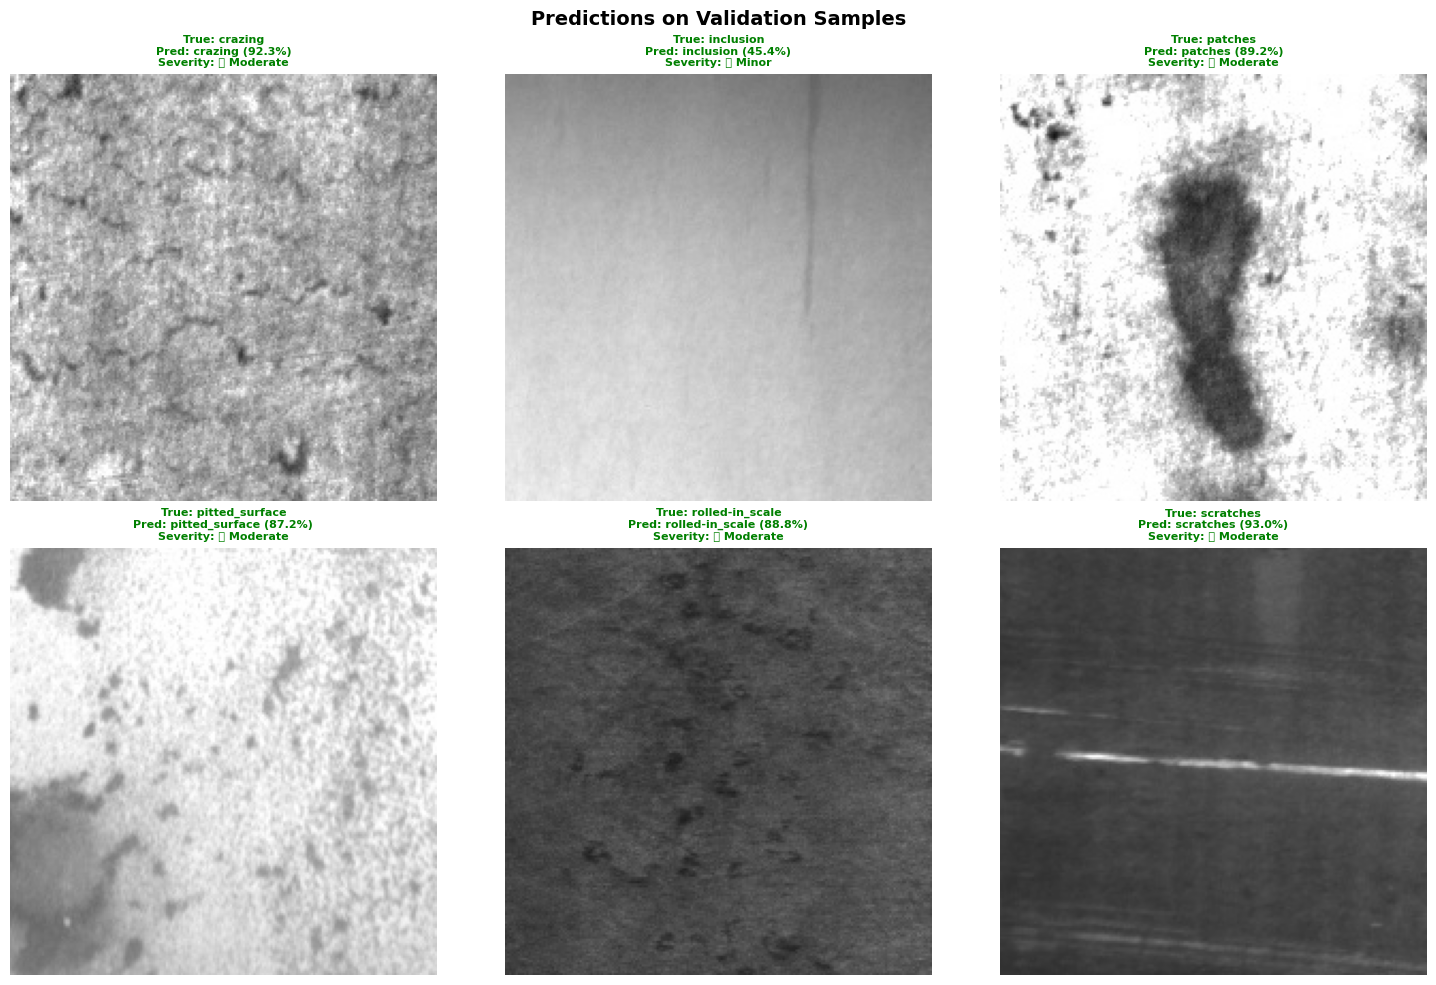

In [19]:
 
 
# ── CELL 19 ── Run on Sample Val Images ──────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
 
for i, cls in enumerate(CLASSES):
    p       = os.path.join(VAL_DIR, cls)
    sample  = os.path.join(p, os.listdir(p)[0])
    print(f"\n{'─'*62}\nSAMPLE: {cls}\n{'─'*62}")
    defect, conf, probs = predict_full(sample)
    generate_pdf_report(defect, conf, probs,
                        f'/kaggle/working/report_{cls}.pdf')
    img = Image.open(sample).convert('RGB')
    color = 'green' if defect == cls else 'red'
    axes[i].imshow(img)
    axes[i].set_title(
        f"True: {cls}\nPred: {defect} ({conf:.1%})\nSeverity: {get_severity(conf)}",
        fontsize=8, color=color, fontweight='bold'
    )
    axes[i].axis('off')
 
plt.suptitle('Predictions on Validation Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
 

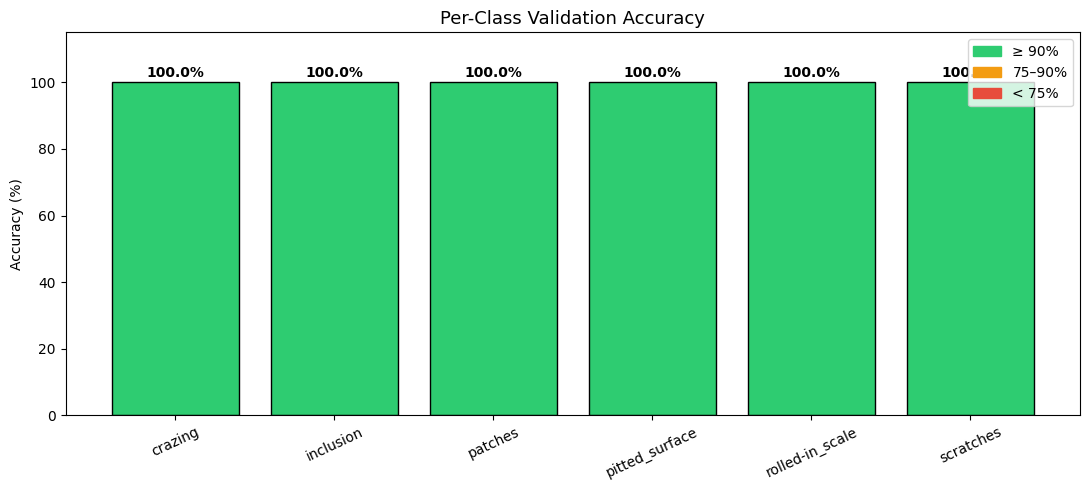

In [20]:
 
# ── CELL 20 ── Per-Class Accuracy ────────────────────────────
per_correct = Counter()
per_total   = Counter()
model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds_batch  = model(imgs).argmax(1)
        for lbl, pred in zip(labels.cpu().numpy(), preds_batch.cpu().numpy()):
            per_total[lbl]   += 1
            if lbl == pred:
                per_correct[lbl] += 1
 
class_accs = {
    IDX_TO_CLASS[i]: per_correct[i] / per_total[i] * 100
    for i in range(NUM_CLASSES)
}
colors_bar = ['#2ecc71' if v >= 90 else '#f39c12' if v >= 75 else '#e74c3c'
               for v in class_accs.values()]
 
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(class_accs.keys(), class_accs.values(), color=colors_bar, edgecolor='black')
ax.set_title('Per-Class Validation Accuracy', fontsize=13)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 115)
ax.tick_params(axis='x', rotation=25)
for bar, val in zip(bars, class_accs.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='≥ 90%'),
    mpatches.Patch(color='#f39c12', label='75–90%'),
    mpatches.Patch(color='#e74c3c', label='< 75%'),
]
ax.legend(handles=legend_patches, loc='upper right')
plt.tight_layout()
plt.savefig('/kaggle/working/per_class_accuracy.png', dpi=150)
plt.show()
 

In [21]:
 
# ── CELL 21 ── Final Summary ──────────────────────────────────
print("\n" + "="*62)
print("  PROJECT : Steel Surface Defect Detection & Root Cause Analysis")
print("  Model   : EfficientNet-B3 (Fine-tuned, last 2 blocks)")
print("  Dataset : NEU Steel Surface Defect (Kaggle)")
print(f"  Classes : {NUM_CLASSES} defect types")
print(f"  Best Val Accuracy : {best_val_acc:.2%}")
print(f"  Best Weighted F1  : {best_f1:.4f}")
print("="*62)
print("\nSaved to /kaggle/working/:")
saved = [
    "best_model.pth", "class_distribution.png", "sample_images.png",
    "training_curves.png", "confusion_matrix.png", "gradcam.png",
    "sample_predictions.png", "per_class_accuracy.png",
    "report_<class>.pdf  (×6 — one per defect class)"
]
for s in saved:
    print(f"  ✓ {s}")
 


  PROJECT : Steel Surface Defect Detection & Root Cause Analysis
  Model   : EfficientNet-B3 (Fine-tuned, last 2 blocks)
  Dataset : NEU Steel Surface Defect (Kaggle)
  Classes : 6 defect types
  Best Val Accuracy : 100.00%
  Best Weighted F1  : 1.0000

Saved to /kaggle/working/:
  ✓ best_model.pth
  ✓ class_distribution.png
  ✓ sample_images.png
  ✓ training_curves.png
  ✓ confusion_matrix.png
  ✓ gradcam.png
  ✓ sample_predictions.png
  ✓ per_class_accuracy.png
  ✓ report_<class>.pdf  (×6 — one per defect class)
